# Tutorial 4 · Predicting Bike Sharing Usage
## 去年的规律，今年还管用吗？

[Lecture 4](Lecture04.md) · [课程目录](README.md) · [矩阵与回归基础](../../learning/foundation-notes/MathForML.md#rank-pseudoinverse)

老师给出两年的共享单车日记录，希望根据天气、日期类别等信息预测每日租车总量。这份学习笔记按原Tutorial4.ipynb的77个单元展开，单元从原文件第一个开始计数。数据直接从原ZIP读取，无需改动原文件。

前半练回归与特征解释，后半的关键问题是：第二年用户变多，旧模型可能系统性低估。给它补上第二年一季度的记录，怎样公平判断调整有没有帮助？

**基础入口（可跳过）：** 不熟数组形状先回[Lecture 1](Lecture01.md#arrays)；不熟平方误差、正则项，先读[Lecture 4](Lecture04.md)。先理解“输入的一行是一天，输出是当天总量”。

| 原任务 | 优先级 | 难度／卡点 | 掌握要求与依据 |
|---|---|---|---|
| Tutorial4，第4–28个单元 数据、one-hot、年份划分 | 核心必会 | 中，特征与目标泄漏 | 能保留原2011/2012划分，解释删除计数列 |
| Tutorial4，第29–47个单元 基线、OLS、Ridge | 核心必会 | 中，CV与误差单位 | 能用训练内部验证选参数并读散点图 |
| Tutorial4，第48–58个单元 LASSO、OMP | 常规掌握 | 中，相关特征与系数含义 | 能比较选择结果，不把权重当因果 |
| Tutorial4，第59–64个单元 非线性回归 | 核心必会 | 中，公平模型比较 | 能固定划分、报告CV和测试各自用途 |
| Tutorial4，第65–76个单元 新年份与三种适应方法 | 核心必会 | 高，数据角色变化 | 能在同一剩余测试集比较四条流程 |

优先级依据当前任务与Lecture4。代码与答案为参考实现，可从头运行；独立尝试题写在说明中。


## 1. Setup｜先固定实验条件

原题未指定随机搜索范围。本参考使用固定种子42，2011年内的五折扩展窗口验证（TimeSeriesSplit），并让验证日期始终晚于对应训练日期。原全年2011训练、2012测试保持。模型参数只看2011验证误差选择；第二年成绩用于教学分析。

English: Hyperparameters are chosen within 2011 using forward chronological validation. The original year-based outer split is preserved. No model is selected using its 2012 test score.

In [1]:
from pathlib import Path
import os
import io, zipfile, hashlib, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, OrthogonalMatchingPursuit
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
REPO = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p/'learning/course-notes-documents.json').is_file()), None)
if REPO is None:
    raise FileNotFoundError('Run this notebook from the CityU-StudyNotes checkout.')
COURSE = Path(os.environ.get('COURSE_DATA_ROOT', str(REPO/'data'))).expanduser().resolve()
DATA = COURSE/'CS5489/Lecture4/Tutorial/Bike-Sharing-Dataset.zip'
if not DATA.is_file():
    raise FileNotFoundError(f'Missing {DATA}; obtain the Canvas data and set COURSE_DATA_ROOT (see docs/DATA.md).')
NOTES = REPO/'CS5489/course-notes'
OUTPUT = NOTES/'execution/Tutorial04'; OUTPUT.mkdir(parents=True, exist_ok=True)
SEED = 42
plt.rcParams.update({'figure.figsize': (8, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
print('Dataset SHA256:', hashlib.sha256(DATA.read_bytes()).hexdigest())

Dataset SHA256: b70182d0d0508e9abbb79306ce5c0cec34869000f8220175ac83d11dbe845401


<a id="2-load-and-inspectt428"></a>


<a id="2-load-and-inspecttutorial4428"></a>
## 2. Load and inspect｜不要把答案偷偷塞进输入

**任务 / Task：** 读取日数据，查看字段与分布，把season、mnth、weekday、weathersit做one-hot，预测cnt，按yr划分。 / Load daily records, inspect features, encode four categorical fields, predict cnt, and split by year.

ZIP同时有hour.csv和day.csv，本题用day.csv。`cnt=casual+registered`：若把后两列放入X，模型已经看到了答案的两个加数。删除它们不是嫌数据多，是因为预测当天总量时不能先知道当天两类人的完整数量。

原说明把weekday写成1–7，实际数据是0–6；代码以数据为准。`instant`仅是记录号；原题删除日期列，但日期仍用于核验顺序。其他预测任务是否使用日期，应根据预测时可获得的信息决定。

来源：Tutorial4，第4–28个单元。


Daily shape: (731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349


,temp,atemp,hum,windspeed,cnt
count,731.00,731.00,731.00,731.00,731.00
mean,0.50,0.47,0.63,0.19,4504.35
std,0.18,0.16,0.14,0.08,1937.21
min,0.06,0.08,0.00,0.02,22.00
25%,0.34,0.34,0.52,0.13,3152.00
50%,0.50,0.49,0.63,0.18,4548.00
75%,0.66,0.61,0.73,0.23,5956.00
max,0.86,0.84,0.97,0.51,8714.00


X columns: ['yr', 'holiday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed', 'season_1', 'season_2', 'season_3', 'season_4', 'mnth_1', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'weekday_0', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'weathersit_1', 'weathersit_2', 'weathersit_3', 'weathersit_4']
train/test: (365, 34) (366, 34)


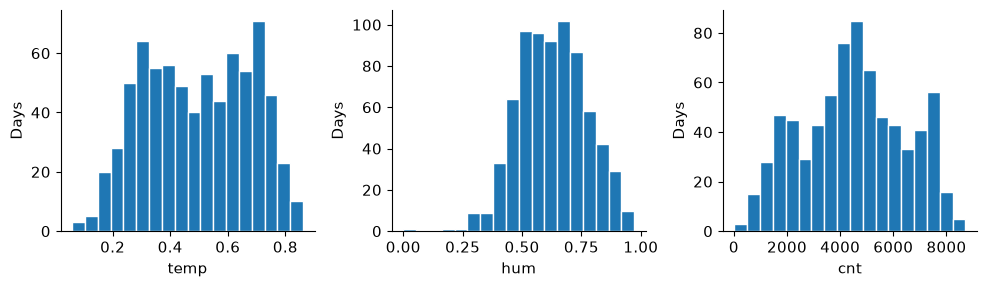

In [2]:
with zipfile.ZipFile(DATA) as archive:
    df = pd.read_csv(io.BytesIO(archive.read('day.csv')))
dates = pd.to_datetime(df['dteday'])
assert len(df) == 731 and dates.is_monotonic_increasing
assert (df['cnt'] == df['casual'] + df['registered']).all()
assert set(df['weekday']) == set(range(7))
print('Daily shape:', df.shape)
display(df.head(3))
display(df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].describe().round(2))
features = df.drop(columns=['instant', 'dteday', 'casual', 'registered', 'cnt'])
# Categories here are fixed calendar/weather codes, not selected from test outcomes.
category_levels = {'season': range(1,5), 'mnth': range(1,13),
                   'weekday': range(7), 'weathersit': range(1,5)}
for col, levels in category_levels.items():
    features[col] = pd.Categorical(features[col], categories=list(levels))
encoded = pd.get_dummies(features, columns=list(category_levels), dtype=float)
X = encoded.to_numpy(dtype=float); y = df['cnt'].to_numpy(dtype=float)
train_mask = df['yr'].to_numpy() == 0
trainX, testX = X[train_mask], X[~train_mask]
trainY, testY = y[train_mask], y[~train_mask]
assert len(trainY) == 365 and len(testY) == 366
assert not {'casual', 'registered', 'cnt'} & set(encoded.columns)
print('X columns:', list(encoded.columns))
print('train/test:', trainX.shape, testX.shape)
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, col in zip(axes, ['temp','hum','cnt']):
    ax.hist(df[col], bins=18, edgecolor='white'); ax.set_xlabel(col); ax.set_ylabel('Days')
fig.tight_layout(); plt.show()

`yr`保留，因为后面合并新旧年份训练要用；只在2011年训练时，这一列全是0，模型没见过它从0变成1，因此学不到这个变化对应的需求差异。固定天气编码中值4在日数据里没有出现，对应列全0；这让列名稳定，不代表观察到了暴雪样本。天气值、连续特征已按数据说明缩放，不再从全部数据估计新的缩放参数。

**自测 / Check：** 保留registered会造成什么？ / What happens if registered remains an input?

答案 / Answer：它是当天总量的一部分，构成目标泄漏，测试成绩不再代表根据事前信息预测需求。 / It leaks part of the target and invalidates the intended advance-demand prediction.

<a id="3-a-baseline-and-interpretable-errorst2947"></a>


<a id="3-a-baseline-and-interpretable-errorstutorial42947"></a>
## 3. A baseline and interpretable errors｜先问模型有没有赢过“每天报同一个数”

DummyRegressor只记训练目标的均值或中位数。它不使用天气等特征，能用来判断复杂模型是否确实增加了预测能力。MSE单位是“租车次数的平方”；RMSE开方后回到次数，MAE也是次数。原Tutorial4，第31个单元文字写MSE，Tutorial4，第32个单元实际代码计算RMSE；本笔记同时列出MSE、RMSE、MAE，避免把平方误差与开方后误差混用。

**任务 / Task：** 拟合基线、OLS、训练内选alpha的Ridge，并比较误差及预测散点。 / Fit dummy, OLS and CV-selected ridge models, then compare errors and scatter plots.

来源：Tutorial4，第29–47个单元。


In [3]:
cv = TimeSeriesSplit(n_splits=5)
for tr, va in cv.split(trainX):
    assert tr.max() < va.min()
def scores(model, a, b):
    pred = model.predict(a)
    return {'MSE': mean_squared_error(b, pred),
            'RMSE': mean_squared_error(b, pred)**0.5,
            'MAE': mean_absolute_error(b, pred)}
models = {'Dummy mean': DummyRegressor(strategy='mean').fit(trainX, trainY),
          'Dummy median': DummyRegressor(strategy='median').fit(trainX, trainY),
          'OLS': LinearRegression().fit(trainX, trainY)}
searches = {}
def tune(name, estimator, grid):
    search = GridSearchCV(estimator, grid, cv=cv,
                          scoring='neg_mean_squared_error', n_jobs=1)
    search.fit(trainX, trainY)
    searches[name] = search; models[name] = search.best_estimator_
    print(name, search.best_params_, 'CV RMSE:', round((-search.best_score_)**0.5, 2))
tune('Ridge', Ridge(), {'alpha': [0.01, 0.1, 1, 10, 100, 1000]})
def comparison(names):
    return pd.DataFrame([{'model': name, 'split': split, **scores(models[name], a, b)}
                         for name in names for split, a, b in
                         [('train 2011', trainX, trainY), ('test 2012', testX, testY)]])
display(comparison(list(models)).round(2))

Ridge {'alpha': 0.01} CV RMSE: 922.02


,model,split,MSE,RMSE,MAE
0,Dummy mean,train 2011,1895753.56,1376.86,1197.75
1,Dummy mean,test 2012,8004985.59,2829.31,2488.67
2,Dummy median,train 2011,2007468.84,1416.85,1172.88
3,Dummy median,test 2012,6649947.46,2578.75,2260.84
4,OLS,train 2011,301709.73,549.28,407.40
5,OLS,test 2012,5285090.49,2298.93,2121.76
6,Ridge,train 2011,301755.25,549.32,407.39
7,Ridge,test 2012,5287279.32,2299.41,2122.63


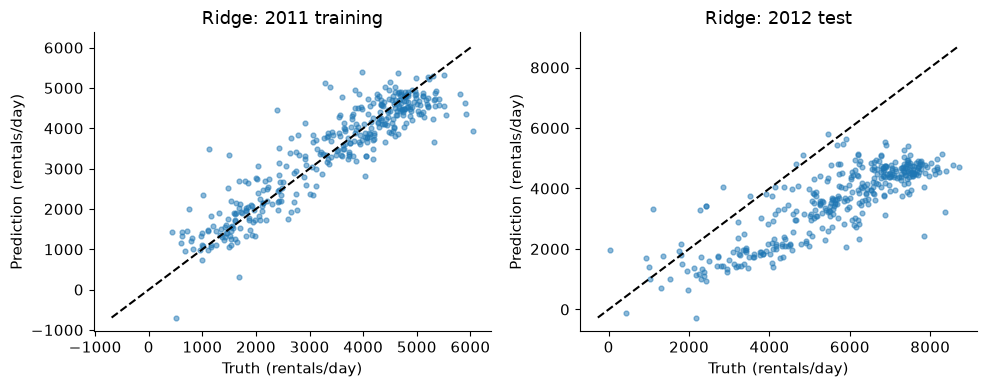

2012 mean residual, truth minus prediction: 2059.93


In [4]:
def scatter(ax, truth, prediction, title):
    ax.scatter(truth, prediction, s=12, alpha=.5)
    low = min(truth.min(), prediction.min()); high = max(truth.max(), prediction.max())
    ax.plot([low,high], [low,high], '--', color='black')
    ax.set(xlabel='Truth (rentals/day)', ylabel='Prediction (rentals/day)', title=title)
fig, axes = plt.subplots(1,2,figsize=(10,4))
scatter(axes[0], trainY, models['Ridge'].predict(trainX), 'Ridge: 2011 training')
scatter(axes[1], testY, models['Ridge'].predict(testX), 'Ridge: 2012 test')
fig.tight_layout();plt.show()
print('2012 mean residual, truth minus prediction:',
      round(float(np.mean(testY-models['Ridge'].predict(testX))),2))

读图先确认横轴！这里沿用老师Tutorial4，第32个单元的代码：横轴truth，纵轴prediction。因此低估在对角线**下方**，与Tutorial4，第66个单元一致。Tutorial4，第34个单元对基线的“x-value predictions”是文字简写，实际横轴仍是真值；读图以轴标签和代码为准。残差定义为真实值减预测值，正均值说明整体低估。

English: With truth on the horizontal axis and prediction on the vertical axis, underprediction lies below the diagonal. A positive mean residual (truth minus prediction) indicates underprediction. 

本次测试RMSE：OLS 2298.93、Ridge 2299.41，二者很接近，OLS略低。与均值基线2829.31相比两者均改善，但第二年的整体低估仍明显。 / OLS slightly outperforms ridge in this run; both improve over the mean baseline, yet year-shift bias remains.

<a id="4-lasso-and-ompt4858"></a>


<a id="4-lasso-and-omptutorial44858"></a>
## 4. LASSO and OMP｜“重要特征”不是一份永久排行榜

LASSO让一些权重恰为0；OMP逐次选择能改善残差的方向，再联合拟合已选特征。原题要求试10个特征，这里照做。`temp`与`atemp`、月份与季节可能相关，两种方法不必选同一批。

**任务 / Task：** 训练LASSO，按绝对系数排序并解释；用OMP选择10个特征，比较两组选择。 / Fit LASSO, interpret the largest absolute coefficients, and compare its selection with 10-feature OMP.

来源：Tutorial4，第48–58个单元。


In [5]:
tune('LASSO', Lasso(max_iter=100000, tol=1e-4), {'alpha': [0.1, 1, 10, 30, 100]})
models['OMP (10)'] = OrthogonalMatchingPursuit(n_nonzero_coefs=10).fit(trainX, trainY)
weights = pd.DataFrame({'feature': encoded.columns,
                        'LASSO': models['LASSO'].coef_, 'OMP': models['OMP (10)'].coef_})
weights = weights.iloc[np.argsort(np.abs(weights['LASSO'].to_numpy()))[::-1]]
display(weights.head(12).round(2))
selected_lasso=set(weights.loc[weights['LASSO'].abs()>1e-8,'feature'])
selected_omp=set(weights.loc[weights['OMP'].abs()>1e-8,'feature'])
print('LASSO count:',len(selected_lasso),'OMP count:',len(selected_omp))
print('Shared selections:',sorted(selected_lasso & selected_omp))
display(comparison(['LASSO','OMP (10)']).round(2))

LASSO {'alpha': 0.1} CV RMSE: 880.14


,feature,LASSO,OMP
3,temp,3091.82,3214.27
6,windspeed,-1977.51,0.00
32,weathersit_3,-1325.85,-1544.45
5,hum,-1281.77,0.00
15,mnth_5,934.80,855.33
7,season_1,-858.67,-780.26
11,mnth_1,-673.79,-212.36
16,mnth_6,639.52,718.33
12,mnth_2,-493.06,0.00
19,mnth_9,428.88,412.04


LASSO count: 28 OMP count: 10
Shared selections: ['mnth_1', 'mnth_5', 'mnth_6', 'mnth_9', 'season_1', 'season_3', 'season_4', 'temp', 'weathersit_1', 'weathersit_3']


,model,split,MSE,RMSE,MAE
0,LASSO,train 2011,301761.36,549.33,407.36
1,LASSO,test 2012,5286640.86,2299.27,2122.48
2,OMP (10),train 2011,348800.84,590.59,439.74
3,OMP (10),test 2012,5522244.40,2349.95,2148.43


比如温度权重为w，温度的归一化值增加0.1、其他输入不变时，预测变化为0.1w；不是增加1°C就变化w。One-hot权重的解释受基线、截距及同组其他类别影响，尤其完整one-hot加截距存在冗余。它描述给定其他输入时模型怎样改预测；实际骑行量还受其他因素影响。

English: Interpret a coefficient in the feature's encoded units, holding other inputs fixed. Correlated predictors can share or exchange weight; selection does not establish causation.

本次LASSO选alpha=0.1，有28个非零系数；OMP按题设选10个。温度系数约3091.82、风速−1977.51、湿度−1281.77（均按原缩放单位）。选择不同并不自动说明谁算错，因为目标与稀疏约束不同。 / The fitted LASSO and ten-feature OMP use different sparsity objectives.

<a id="5-nonlinear-regressiont5964"></a>


<a id="5-nonlinear-regressiontutorial45964"></a>
## 5. Nonlinear regression｜让比较只改变模型

这里选原Lecture4中的RBF核岭回归与随机森林作两条参考路线。参数网格由本参考实现选定。每条路线用同一2011时间验证折，选定模型后才汇报2012。

**独立尝试 / Try：** 另加一种Lecture4模型，保持划分与误差单位，比较训练验证RMSE。 / Add another Lecture4 model while preserving splits and evaluation units.

来源：Tutorial4，第59–64个单元。


RBF kernel ridge {'alpha': 0.1, 'gamma': 0.01} CV RMSE: 1209.35


Random forest {'max_depth': None, 'min_samples_leaf': 2} CV RMSE: 917.85


,model,CV_RMSE,parameters
1,LASSO,880.14,{'alpha': 0.1}
3,Random forest,917.85,"{'max_depth': None, 'min_samples_leaf': 2}"
0,Ridge,922.02,{'alpha': 0.01}
2,RBF kernel ridge,1209.35,"{'alpha': 0.1, 'gamma': 0.01}"


Selected before the adaptation comparison, by 2011 CV: LASSO


,model,split,MSE,RMSE,MAE
0,Dummy mean,train 2011,1895753.56,1376.86,1197.75
1,Dummy mean,test 2012,8004985.59,2829.31,2488.67
2,Dummy median,train 2011,2007468.84,1416.85,1172.88
3,Dummy median,test 2012,6649947.46,2578.75,2260.84
4,OLS,train 2011,301709.73,549.28,407.40
5,OLS,test 2012,5285090.49,2298.93,2121.76
6,Ridge,train 2011,301755.25,549.32,407.39
7,Ridge,test 2012,5287279.32,2299.41,2122.63
8,LASSO,train 2011,301761.36,549.33,407.36
9,LASSO,test 2012,5286640.86,2299.27,2122.48


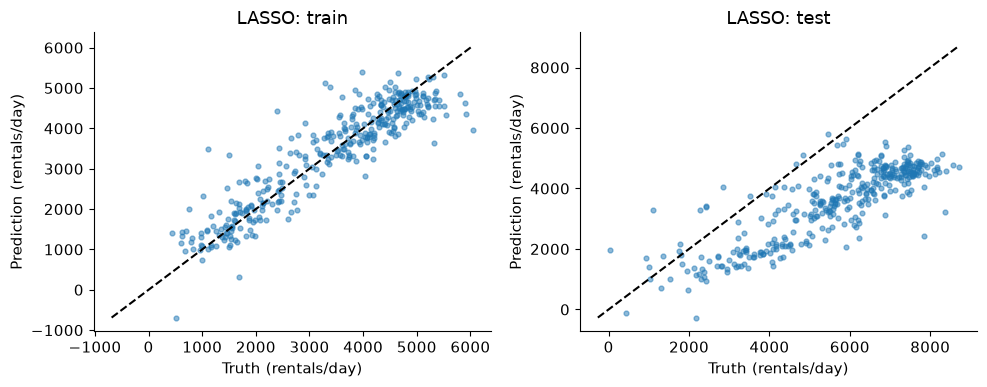

In [6]:
tune('RBF kernel ridge', KernelRidge(kernel='rbf'),
     {'alpha': [0.1, 1, 10], 'gamma': [0.01, 0.1, 1]})
tune('Random forest', RandomForestRegressor(n_estimators=120, random_state=SEED, n_jobs=1),
     {'max_depth':[5, None], 'min_samples_leaf':[2, 8]})
cv_table = pd.DataFrame([{'model':name,'CV_RMSE':(-search.best_score_)**0.5,
                          'parameters':str(search.best_params_)} for name,search in searches.items()]).sort_values('CV_RMSE')
display(cv_table.round(2))
chosen = cv_table.iloc[0]['model']; bestr = models[chosen]
print('Selected before the adaptation comparison, by 2011 CV:',chosen)
display(comparison(list(models)).round(2))
fig, axes = plt.subplots(1,2,figsize=(10,4))
scatter(axes[0],trainY,bestr.predict(trainX),chosen+': train')
scatter(axes[1],testY,bestr.predict(testX),chosen+': test')
fig.tight_layout();plt.show()

训练得最好不等于跨年最好。树擅长分区间，RBF依靠与训练样本的相似性；面对整体需求变化，两者都可能失效。先按2011年的验证结果选模型，再观察它在2012年表现怎样；下面的结果展示了两者可能不同。

English: Compare the printed scores, and distinguish the CV-selected model from the model that happens to score best on the test table. Flexible functions alone do not solve temporal distribution shift.

2011时间验证选出LASSO，故后续适应实验固定它。事后2012表中随机森林RMSE最低（2205.32），这一事后排名不用于改变后续已固定的方法。非线性候选没有赢得本次训练内选择。 / LASSO wins the training-only selection; the test-table winner is not used to revise that choice.

<a id="6-test-set-biast6576"></a>


<a id="6-test-set-biastutorial46576"></a>
## 6. Test set bias｜先把新增数据的角色划清楚

画总量随日期变化，再模拟老师给定的情境：2012年1–3月已经结束，其标签现在可用；把它当新训练数据，4–12月仍只作评估。不能一边用一季度调模型，一边把它算进最终测试成绩。

筛选第二年一季度时，参考实现直接使用原表的mnth月份字段，取得与课堂方案相同的记录：91天新训练，275天剩余测试。特征仍按同一列顺序。来源注：Tutorial4，第69个单元按第11–13列取月份；依赖列位置的写法需核对编码后的列顺序。

**任务 / Task：** 固定一种已选回归方法，比较旧模型、新数据单独重训、合并重训、学习旧模型残差；全部在同一个4–12月测试集评估。 / Compare the original model, new-only retraining, pooled retraining, and residual adaptation on the same April–December holdout.

来源：Tutorial4，第65–76个单元。


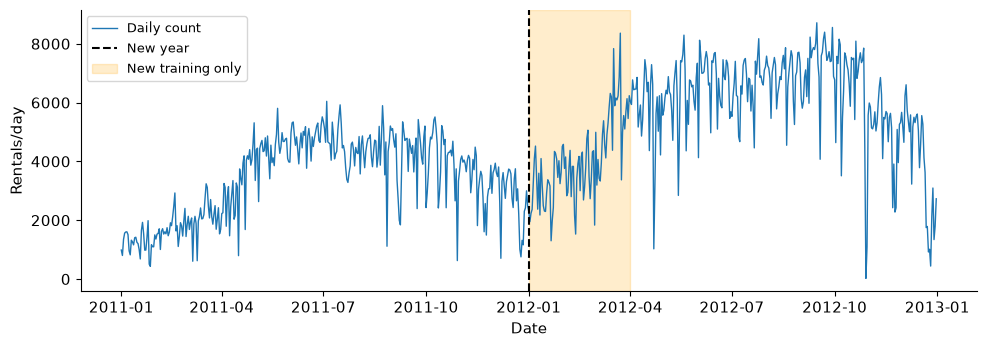

,approach,RMSE,MAE,mean residual
0,Original 2011 model,2311.86,2139.80,2056.39
1,New Jan-Mar only,1281.87,1023.65,-231.20
2,Pooled 2011 + Jan-Mar,1042.12,817.28,124.93
3,Residual correction,1832.61,1420.41,-1362.37


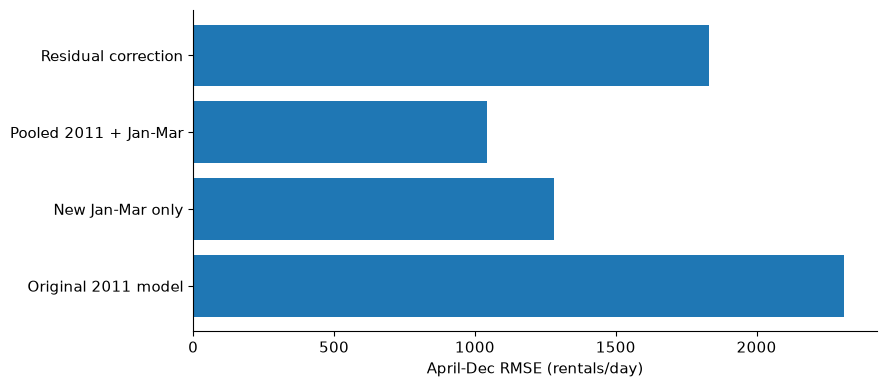

In [7]:
new_mask=(df['yr'].to_numpy()==1)&(df['mnth'].to_numpy()<=3)
holdout_mask=(df['yr'].to_numpy()==1)&(df['mnth'].to_numpy()>=4)
newX,newY=X[new_mask],y[new_mask];holdX,holdY=X[holdout_mask],y[holdout_mask]
assert len(newY)==91 and len(holdY)==275
assert not np.any(train_mask & new_mask) and not np.any(new_mask & holdout_mask)
fig, ax=plt.subplots(figsize=(10,3.6))
ax.plot(dates,y,lw=1,label='Daily count')
ax.axvline(pd.Timestamp('2012-01-01'),color='black',ls='--',label='New year')
ax.axvspan(pd.Timestamp('2012-01-01'),pd.Timestamp('2012-04-01'),alpha=.2,color='orange',label='New training only')
ax.set(xlabel='Date',ylabel='Rentals/day');ax.legend(fontsize=9);fig.tight_layout();plt.show()
new_only=clone(bestr).fit(newX,newY)
pooled=clone(bestr).fit(np.vstack([trainX,newX]),np.r_[trainY,newY])
# Correct a truth-minus-prediction residual by ADDING the learned residual.
residual_model=clone(bestr).fit(newX,newY-bestr.predict(newX))
predictions={'Original 2011 model':bestr.predict(holdX),
             'New Jan-Mar only':new_only.predict(holdX),
             'Pooled 2011 + Jan-Mar':pooled.predict(holdX),
             'Residual correction':bestr.predict(holdX)+residual_model.predict(holdX)}
adaptation=pd.DataFrame([{'approach':name,'RMSE':mean_squared_error(holdY,pred)**.5,
                          'MAE':mean_absolute_error(holdY,pred),
                          'mean residual':float(np.mean(holdY-pred))}
                         for name,pred in predictions.items()])
display(adaptation.round(2))
fig,ax=plt.subplots(figsize=(9,4))
ax.barh(adaptation['approach'],adaptation['RMSE']);ax.set_xlabel('April-Dec RMSE (rentals/day)')
fig.tight_layout();plt.show()

残差方法像给旧地图贴修订便签：旧模型负责已有规律，新模型学“还差多少”。约定$r=y-f_{old}(x)$时，加上$\hat r$；若把残差反过来定义为$f_{old}(x)-y$，修正时必须减。原题文字没有把这个符号约定讲透，实施时不能前后混用。

三种方法都不保证最好。新数据只有冬末春初，单独训练可能看不到夏季；合并数据覆盖更广，但旧年份占比大；残差法保留旧季节形状，却也依赖“差值规律能迁移到后九个月”的假设。比较时结合上表误差和这些假设解释结果。

**迁移题 / Transfer：** 若现在只到2012年2月底，可以拿3月数据选参数吗？为什么？ / If it is only the end of February 2012, may March observations be used for tuning an operational predictor?

<details markdown="1"><summary>答案 / Answer</summary>

不能，3月结果尚不可得；应把可用日期以前的数据进一步按时间拆分。离线已下载全年数据不代表当时可见。 / No. March outcomes are not yet available. Validation must reflect the information available at the prediction date.

</details>

本次相同275天测试集上，旧模型、新数据单独、合并、残差修正RMSE分别为2311.86、1281.87、1042.12、1832.61。合并方案最好；残差修正仍有明显过预测，平均真值减预测为−1362.37，提示早春的偏差规律未充分代表其余季节。 / Pooled retraining is best in this run; residual adaptation overpredicts the held-out months.


## 7. Return to the lecture｜把结果变成能解释的结论

英文自测 / English self-test：Why were the count components removed? Why split by year? Why does a constant year feature fail to teach the next year's offset? Why must all adaptation methods share the same holdout?

中文题意：为什么删去两项计数组成？为什么按年份划分？训练中恒定的年份特征为何学不到下一年偏移？为什么适应方法必须使用同一测试集？

关键答案 / Key answers：避免目标泄漏；评估向未来迁移；训练中无变化的特征无法识别变化效应；同一测试集才有可比较的误差。 / Prevent target leakage; evaluate future transfer; a constant feature cannot identify a changing effect; compare errors on identical held-out records.

首轮复习沿用[回归 M187](https://crazyshout.github.io/micro-course/cards.html#CS5489-M187)、[Ridge M194](https://crazyshout.github.io/micro-course/cards.html#CS5489-M194)、[LASSO M196](https://crazyshout.github.io/micro-course/cards.html#CS5489-M196)，再回[ML19](https://crazyshout.github.io/micro-course/?lesson=ml19)串起目标、约束与验证。

| 原课单元 | 本笔记位置 |
|---|---|
| Tutorial4，第1–3个单元 姓名/任务/初始化 | 开头与§1，个人身份不填入公共学习稿 |
| Tutorial4，第4–28个单元 原数据、分布、统计、编码、提取与年份划分 | §2 |
| Tutorial4，第29–35个单元 Dummy与误差/散点 | §3 |
| Tutorial4，第36–47个单元 OLS/Ridge与解释 | §3 |
| Tutorial4，第48–58个单元 LASSO/OMP与系数 | §4 |
| Tutorial4，第59–64个单元 非线性模型 | §5 |
| Tutorial4，第65–76个单元 趋势及三种再训练 | §6 |
| Tutorial4，第77个单元 空单元 | 无教学内容 |

结果由以上代码产生，采用§1的固定设置。

In [8]:
report={'dataset_sha256':hashlib.sha256(DATA.read_bytes()).hexdigest(),
        'shape':list(X.shape),'train_rows':len(trainY),'test_rows':len(testY),
        'new_rows':len(newY),'holdout_rows':len(holdY),'selected_model':chosen,
        'cv':cv_table.to_dict(orient='records'),
        'scores':comparison(list(models)).to_dict(orient='records'),
        'adaptation':adaptation.to_dict(orient='records')}
(OUTPUT/'results.json').write_text(json.dumps(report,indent=2)+'\n')
# Save predictions for independent recomputation; this is not a submission file.
np.savez(OUTPUT/'verification-arrays.npz',truth=holdY,**{f'pred_{i}':v for i,v in enumerate(predictions.values())})
print('Learning-run results saved; original materials unchanged.')

Learning-run results saved; original materials unchanged.
